In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

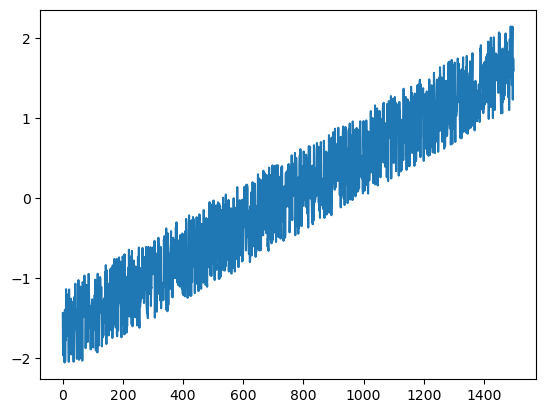

In [2]:
X = np.array(range(1500))
Y = 5 * X + 3 + np.random.randint(-800, 1600, 1500)

X = (X - np.mean(X)) / np.std(X) 
Y = (Y - np.mean(Y)) / np.std(Y)

lr = 0.1
N = len(X)

sns.lineplot(Y)
plt.show()

## Градиентный спуск

Коэффициент наклона: 0.9508 Свободный член: 0.0001
Количество итераций: 44


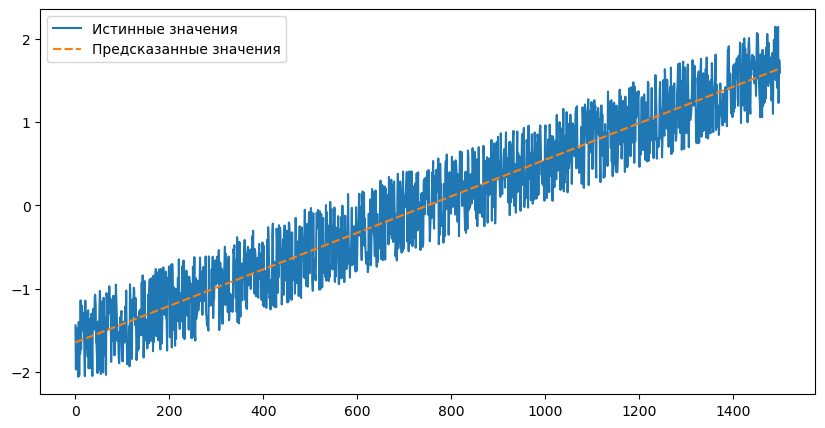

CPU times: total: 172 ms
Wall time: 179 ms


In [3]:
%%time

a0 = np.random.normal(0, 1, 1)
b0 = np.random.normal(0, 1, 1)
i0 = 0
error1 = float('inf')

while i0 <= 10000:
     f = X * a0 + b0

     error0 = np.mean((f - Y) ** 2)

     dl_da = 2 / N * np.sum((f - Y) * X)
     dl_db = 2 / N * np.sum(f - Y)
     
     a0 -= lr * dl_da
     b0 -= lr * dl_db

     if abs(error1 - error0) <= 1e-8:
          break
     
     error1 = error0
     i0 += 1

print('Коэффициент наклона:', np.round(a0[0], 4), 'Свободный член:', np.round(b0[0], 4)) 
print('Количество итераций:', i0)
Y0 = a0 * X + b0
plt.figure(figsize=(10, 5))
sns.lineplot({'Истинные значения': Y, 'Предсказанные значения': Y0})
plt.show()

## Стохастический градиентный спуск

Коэффициент наклона: 0.9528 Свободный член: -0.0008
Количество итераций: 15000


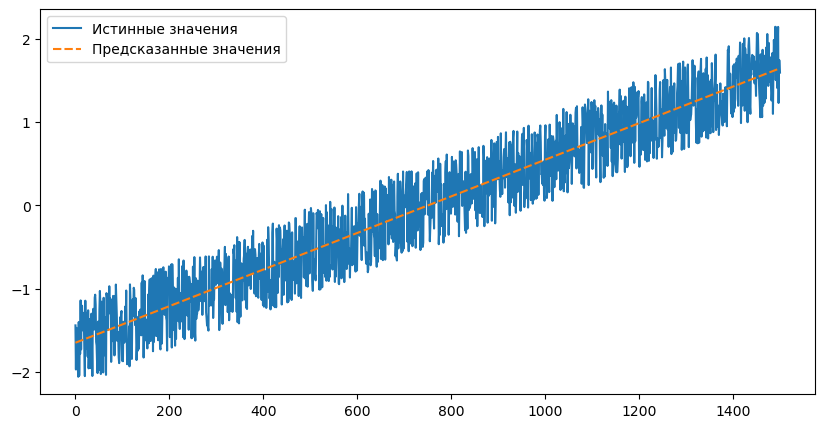

CPU times: total: 562 ms
Wall time: 562 ms


In [6]:
%%time

a1 = np.random.normal(0, 1, 1)
b1 = np.random.normal(0, 1, 1)

epoch = 0
error1 = float('inf')
batch_size = 100
batch_count = N // batch_size
i1 = 0

while epoch < 1000:

     indices = np.random.permutation(N)
     X_shuffled = X[indices]
     Y_shuffled = Y[indices]

     for b in range(batch_count):
          X1 = X_shuffled[b *  batch_size : b * batch_size + batch_size]
          Y1 = Y_shuffled[b * batch_size : b * batch_size + batch_size]

          f1 = X1 * a1 + b1

          dl_da = 2 / batch_size  * np.sum((f1 - Y1) * X1)
          dl_db = 2 / batch_size * np.sum(f1 - Y1)

          a1 -= lr * dl_da
          b1 -= lr * dl_db

     f = X_shuffled * a1 + b1

     error0 = np.mean((f - Y_shuffled) ** 2)
     if abs(error1 - error0) <= 1e-8:
          break
     
     error1 = error0
     epoch += 1
     i1 += batch_count

print('Коэффициент наклона:', np.round(a1[0], 4), 'Свободный член:', np.round(b1[0], 4)) 
print('Количество итераций:', i1)
Y1 = a1 * X + b1
plt.figure(figsize=(10, 5))
sns.lineplot({'Истинные значения': Y, 'Предсказанные значения': Y1})
plt.show()

## Accelerated Gradient Descend

Коэффициент наклона: 0.951 Свободный член: 0.0
Количество итераций: 44


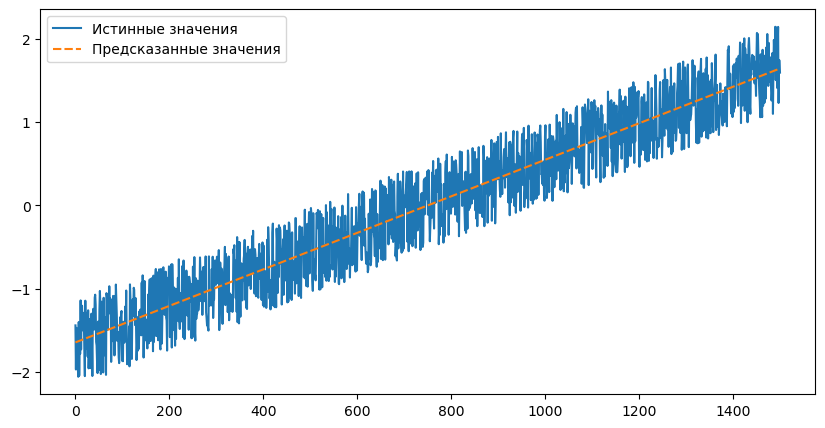

CPU times: total: 172 ms
Wall time: 172 ms


In [8]:
%%time

a2 = np.random.normal(0, 1, 1)
b2 = np.random.normal(0, 1, 1)
i2 = 0
error1 = float('inf')
Va, Vb = 0, 0
beta = 0.9

while i2 <= 10000:
     a_nesterov = a2 + beta * Va
     b_nesterov = b2 + beta * Vb
    
     f_nesterov = a_nesterov * X + b_nesterov

     dl_da = 2 / N * np.sum((f_nesterov - Y) * X)
     dl_db = 2 / N * np.sum(f_nesterov - Y)

     Va = beta * Va - lr * dl_da
     a2 += Va

     Vb = beta * Vb - lr * dl_db
     b2 += Vb

     f = a2 * X + b2

     error0 = np.mean((f - Y) ** 2)
     if abs(error1 - error0) <= 1e-8:
          break
     
     error1 = error0
     i2 += 1

print('Коэффициент наклона:', np.round(a2[0], 4), 'Свободный член:', np.round(b2[0], 4)) 
print('Количество итераций:', i2)
Y2 = a2 * X + b2
plt.figure(figsize=(10, 5))
sns.lineplot({'Истинные значения': Y, 'Предсказанные значения': Y2})
plt.show()

## ADAptive GRADient descend

Коэффициент наклона: 0.9503 Свободный член: -0.0
Количество итераций: 565


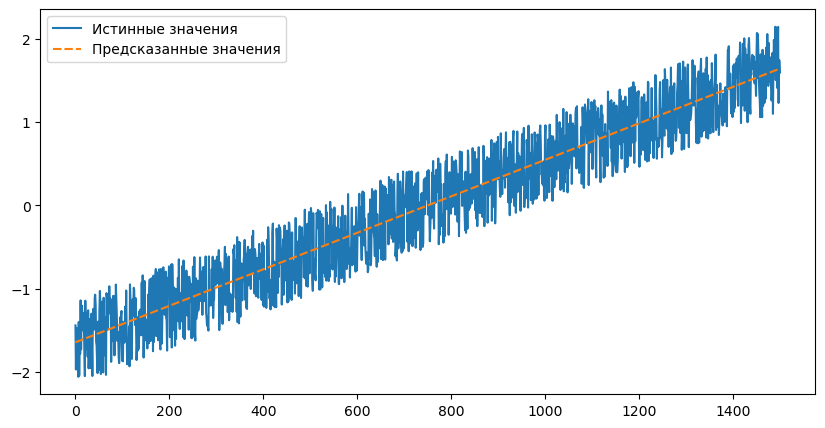

CPU times: total: 188 ms
Wall time: 181 ms


In [9]:
%%time

a3, b3 = np.random.normal(0, 1, 1), np.random.normal(0, 1, 1)
i3 = 0
error1 = float('inf')
Ga, Gb = 0, 0
epsilon = 0.0001

while i3 <= 10000:
     f = X * a3 + b3

     error0 = np.mean((f - Y) ** 2)

     dl_da = 2 / N * np.sum((f - Y) * X)
     dl_db = 2 / N * np.sum(f - Y)

     Ga += dl_da ** 2
     Gb += dl_db ** 2
     # Всегда растёт
     
     a3 -= lr / np.sqrt(Ga + epsilon) * dl_da
     b3 -= lr / np.sqrt(Gb + epsilon) * dl_db
     # Всегда уменьшается шаг, в какой-то момент становится близким к 0

     if abs(error1 - error0) <= 1e-8:
          break
     
     error1 = error0
     i3 += 1

print('Коэффициент наклона:', np.round(a3[0], 4), 'Свободный член:', np.round(b3[0], 4)) 
print('Количество итераций:', i3)
Y3 = a3 * X + b3
plt.figure(figsize=(10, 5))
sns.lineplot({'Истинные значения': Y, 'Предсказанные значения': Y3})
plt.show()

## Root Mean Square Propagation

Коэффициент наклона: 0.9509 Свободный член: -0.0
Количество итераций: 14


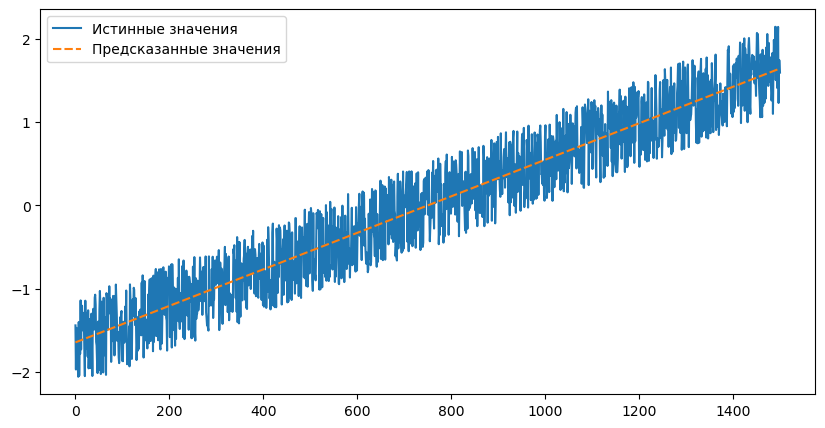

CPU times: total: 156 ms
Wall time: 165 ms


In [10]:
%%time

a4, b4 = np.random.normal(0, 1, 1), np.random.normal(0, 1, 1)
i4 = 0
error1 = float('inf')
Ga, Gb = 0, 0
epsilon = 0.0001
gamma = 0.9

while i4 <= 10000:
     f = X * a4 + b4

     error0 = np.mean((f - Y) ** 2)

     dl_da = 2 / N * np.sum((f - Y) * X)
     dl_db = 2 / N * np.sum(f - Y)

     Ga = gamma * Ga + (1 - gamma) * dl_da ** 2
     Gb = gamma * Gb + (1 - gamma) * dl_db ** 2
     
     a4 -= lr / np.sqrt(Ga + epsilon) * dl_da
     b4 -= lr / np.sqrt(Gb + epsilon) * dl_db

     if abs(error1 - error0) <= 1e-8:
          break
     
     error1 = error0
     i4 += 1

print('Коэффициент наклона:', np.round(a4[0], 4), 'Свободный член:', np.round(b4[0], 4)) 
print('Количество итераций:', i4)
Y4 = a4 * X + b4
plt.figure(figsize=(10, 5))
sns.lineplot({'Истинные значения': Y, 'Предсказанные значения': Y4})
plt.show()

## ADAptive Momentum

Коэффициент наклона: 0.9512 Свободный член: -0.0001
Количество итераций: 156


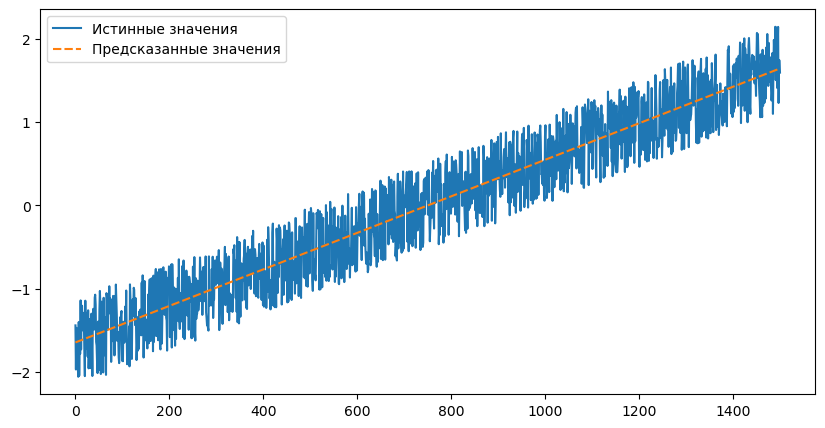

CPU times: total: 172 ms
Wall time: 170 ms


In [11]:
%%time

a5, b5 = np.random.normal(0, 1, 1), np.random.normal(0, 1, 1)
i5 = 0
error1 = float('inf')
Ga, Gb = 0, 0
Va, Vb = 0, 0
epsilon = 1e-8
beta1 = 0.9
beta2 = 0.999

while i5 <= 10000:
     f = X * a5 + b5

     error0 = np.mean((f - Y) ** 2)

     dl_da = 2 / N * np.sum((f - Y) * X)
     dl_db = 2 / N * np.sum(f - Y)

     Va = beta1 * Va + (1 - beta1) * dl_da
     Vb = beta1 * Vb + (1 - beta1) * dl_db

     Ga = beta2 * Ga + (1 - beta2) * dl_da ** 2
     Gb = beta2 * Gb + (1 - beta2) * dl_db ** 2
     
     a5 -= lr / np.sqrt(Ga + epsilon) * Va
     b5 -= lr / np.sqrt(Gb + epsilon) * Vb

     if abs(error1 - error0) <= 1e-8:
          break
     
     error1 = error0
     i5 += 1

print('Коэффициент наклона:', np.round(a5[0], 4), 'Свободный член:', np.round(b5[0], 4)) 
print('Количество итераций:', i5)
Y5 = a5 * X + b5
plt.figure(figsize=(10, 5))
sns.lineplot({'Истинные значения': Y, 'Предсказанные значения': Y5})
plt.show()

In [13]:
import pandas as pd

Корреляция данных и метода Gradient: 0.9508894075692421
Корреляция данных и метода Stochastic Gradient: 0.9508894075692426
Корреляция данных и метода Accelerated Gradient: 0.9508894075692421
Корреляция данных и метода ADAGrad: 0.9508894075692421
Корреляция данных и метода RMSProb: 0.9508894075692421
Корреляция данных и метода ADAM: 0.950889407569242


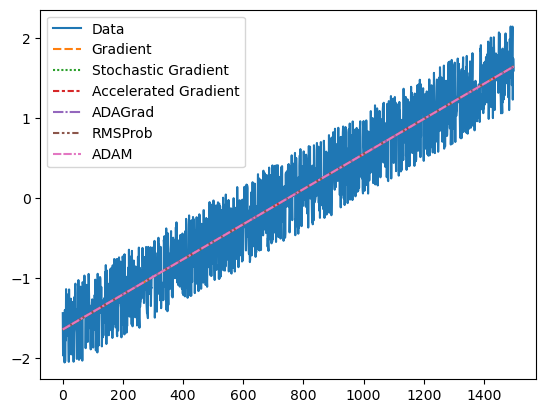

In [14]:
grad_data = pd.DataFrame(data=np.array([Y, Y0, Y1, Y2, Y3, Y4, Y5]).T, 
columns=['Data', 'Gradient', 'Stochastic Gradient', 'Accelerated Gradient', 'ADAGrad', 'RMSProb', 'ADAM'])

for i in grad_data.columns[1::]:
    print(f'Корреляция данных и метода {i}:', grad_data['Data'].corr(grad_data[i]))

sns.lineplot(grad_data)
plt.show()